## Why Not Use Fully Connected Layers for Images?

- Suppose an image is: 224 × 224 × 3

### How many input features does that become?

- Their will be 150528 input features.

### What happens to parameter count if we connect every pixel to every neuron?

- Every neuron in the first hidden layer connects to every input pixel. Therefore the number of learnable weights grows as input features × hidden neurons, causing millions of parameters even for a relatively small hidden layer.

### Why does this become impractical?

- When resolution of image is high their will be to many pixel and that neural network with that much input parameters will need too much memory and computational power to store and process the parameter tensors and model this large needs large dataset to generalize well and is more prone to overfitting also inefficient learning because spatial structure is ignored as nearby pixels are much more related than distant pixels in image CNNs exploit this property.


## Images Are Not Ordinary Tables

### What information exists in images that tabular data does not?

- Images contain spatial information. A pixel's meaning depends on the values of nearby pixels, allowing local patterns such as edges, textures, and shapes to emerge. In contrast, in most tabular datasets each row represents an independent observation, so neighboring rows generally do not carry spatial meaning.

### Why do neighboring pixels matter?

- Neighboring pixels matter because visual features such as edges, corners, textures, and object boundaries are formed by local pixel relationships rather than individual pixel values. By learning these local patterns, CNNs can build increasingly complex visual representations in deeper layers.

- Since the same filter is applied across the image, these learned patterns can also be recognized when they appear in different locations.


## What Is a Convolution?

- Convolution is a fundamental mathematical operation that combines two functions to produce a third function, representing how the shape of one function is modified by the other. It is formally defined as the integral of the product of two functions after one is reflected about the y-axis and shifted across the other.

- The operation works by sliding one function (often called a kernel or filter) over another, multiplying their values at each point of overlap, and summing the results. This process effectively calculates the amount of overlap between the two functions as one is displaced relative to the other.

### Suppose we have this image:

- Image :-

                1 2 0 1
                3 1 2 0
                0 2 1 3
                1 0 2 1

- Instead of connecting every pixel to every neuron (like an MLP (Multilayer Perceptron)), we take a small window. Example: 3 x 3 and this window is called `Kernel` or `Filter`.


## What is kernel?

- A kernel (or filter) is a small matrix of learnable weights that slides across an input image.

- At each position, the kernel performs element-wise multiplication with the corresponding image region and sums the results to produce a single value in the output feature map.

- Initially, kernel values are random. During training, they are updated through backpropagation so that they learn useful visual patterns such as edges, textures, and corners.

### Why is the kernel much smaller than the image?

- A small kernel dramatically reduces the number of learnable parameters compared to connecting every pixel to every neuron.

- It also exploits the fact that neighboring pixels are highly correlated. Local regions contain meaningful visual features such as edges, corners, and textures, so the network does not need to analyze the entire image at once to begin learning useful representations.

### Is the Kernel Fixed or Learned?

- The kernel is **learned**, not fixed.

- Its values are initialized randomly and treated as trainable parameters.

- During training, backpropagation computes gradients for each kernel weight, and the optimizer updates those weights to minimize the loss function.

- As training progresses, different kernels learn to detect different visual features such as edges, textures, and object parts.


## Convolution Operation

- Take the first 3 × 3 region from the input image.

- Image Region

                1 2 0
                3 1 2
                0 2 1

- Kernel

                1  0 -1
                1  0 -1
                1  0 -1

- Perform element-wise multiplication:

                (1 × 1) + (2 × 0) + (0 × -1) + (3 × 1) + (1 × 0) + (2 × -1) + (0 × 1) + (2 × 0) + (1 × -1)

- Finally, sum all the resulting values. That single value becomes one element of the output feature map.

### Why do we perform element-wise multiplication?

- Element-wise multiplication compares the values of the input image patch with the corresponding kernel weights.

- Each multiplication measures how well a local pixel contributes to the pattern represented by the kernel. The combined result produces a single scalar that quantifies how strongly the learned feature is present at that location.

- Initially, the kernel contains random weights, but after training it learns to respond to meaningful visual patterns such as edges, textures, or corners.

### Why do we sum the products instead of keeping them separate?

- Each element-wise multiplication measures the contribution of one pixel to the learned pattern.

- Summing these products combines all local contributions into a single scalar value that represents the overall similarity between the image patch and the kernel.

- This scalar becomes one value in the feature map, indicating how strongly that feature is present at that location.

### What information does this single output value represent about the corresponding image region?

- The final scalar value represents the activation level or response strength of a specific learned feature at that exact location in the input image. A high positive value indicates a strong match between the local image patch and the pattern the filter has learned to detect (e.g., a vertical edge or a specific texture). Conversely, a low or negative value suggests the feature is absent or does not match the filter's pattern.


## Sliding the Kernel

### Why Does the Kernel Slide?

- A kernel only analyzes a small local region of the image at a time. To extract features from the entire image, it must slide across every valid location.

- At each position, the kernel computes a new response value, allowing the network to determine where the learned feature appears within the image.

### Why is the same kernel reused everywhere?

- The same kernel is applied across the entire image because the same visual feature can appear at different locations.

- By reusing one set of weights, the network can detect the same learned pattern—such as an edge or texture—anywhere in the image without learning separate parameters for every position.

- This property is known as weight sharing.

### What advantage does sharing the same weights provide?

- Weight sharing provides two major advantages:
    - Fewer learnable parameters, which reduces memory usage, computation, and the risk of overfitting.
    - Location-independent feature detection, allowing the same kernel to recognize a learned pattern regardless of where it appears in the image.


## What Does the Kernel Learn?

- A kernel is a small matrix of learnable weights that is initialized randomly.

- During training, backpropagation computes gradients for these weights, and the optimizer updates them to minimize the loss.

- As training progresses, different kernels learn to respond strongly to different local visual patterns such as edges, corners, textures, or more complex object parts.

### Why does gradient descent modify kernel values?

- Gradient descent updates the kernel weights to minimize the loss function.

- Backpropagation computes how each kernel weight contributes to the prediction error, and the optimizer adjusts those weights in the direction that reduces the loss.

- As a result of these updates, kernels gradually learn to detect useful visual patterns that improve the model's predictions.

### Why can one kernel detect vertical edges while another detects horizontal edges?

- Each kernel has its own set of learnable weights.

- Because kernels are initialized with different random values and receive different gradient updates during training, they gradually specialize in detecting different visual patterns.

- As a result, one kernel may respond strongly to vertical edges, while another learns to detect horizontal edges, textures, or other local features.


## Output of a Convolution (Feature Map)

- The output of a convolution is a feature map, which is a matrix of scalar values.

- Each scalar represents how strongly the corresponding local image region matches the pattern learned by the kernel.

- Because each value is produced from a specific location in the input image, the feature map preserves spatial information and indicates where the learned feature is present.

### Why is it called a feature map?

- It is called a feature map because each value represents the activation strength of a learned feature at a specific location in the input image.

- The position of each value corresponds to a particular image region, allowing the network to know both what feature was detected and where it was detected.

### What does a high value in the feature map indicate?

- A high value indicates that the local image patch strongly matches the pattern learned by the kernel.

- This means the feature detector has produced a strong activation, suggesting that the corresponding visual feature is present at that location.

### Why does one convolution produce one feature map?

- Each filter learns a single type of visual feature.

- As the filter slides across the image, it computes an activation value at every valid location.

- Collecting all these activation values forms one feature map, showing where that particular learned feature appears throughout the image.

### Why do modern CNNs use many filters?

- Different visual features require different detectors.

- Each filter learns to recognize a particular pattern, such as an edge, corner, texture, or more complex object part.

- Using many filters allows the network to extract a diverse set of features from the same image, enabling deeper layers to combine these simpler features into increasingly complex representations.


## Why Convolution Works Better Than Fully Connected Layers

- Convolution assumes that neighboring pixels are highly correlated and that meaningful visual features can be extracted from small local regions of an image.

- Instead of connecting every pixel to every neuron, CNNs learn local patterns using small filters that are shared across the entire image.

- This preserves spatial information while dramatically reducing the number of learnable parameters.

### Why is locality a good assumption for images?

- Images contain spatial structure, meaning neighboring pixels usually belong to the same object or visual pattern.

- Important features such as edges, corners, and textures are formed by local pixel relationships, making small receptive fields sufficient for learning useful representations.

### Would this assumption work equally well for tabular data?

- Generally, no.

- Most tabular datasets do not have meaningful spatial relationships between neighboring features, so applying local filters provides little benefit.

- However, data with inherent ordering, such as time series or sequences, can benefit from locality-based models because neighboring values are often correlated.

### Parameter Comparison

- Suppose:
    - Image: 224 × 224 × 3
    - One convolution filter: 3 × 3

### How many learnable weights does one filter have?

- 3 × 3 × 3 = 27 weights + 1 bias = 28 learnable parameters

### Why is this dramatically smaller than a fully connected layer?

- A convolution filter contains only a small number of learnable weights and is reused across every location in the image.

- Instead of learning separate weights for every input-output connection, the same filter is applied repeatedly to different image regions.

- This weight sharing dramatically reduces the number of parameters while still allowing the network to detect the same feature anywhere in the image.


## Stride


- Stride is the number of pixels the kernel moves after performing one convolution operation.


In [47]:
import torch
import triton

torch.nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    stride=1
)

Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))

### Visual Representation

- Suppose we have a 5 × 5 image and a 3 × 3 kernel.

- If Stride = 1 then The kernel visits every possible position.

            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+

- Move right by 1

            +---+---+---+---+---+
            |   | X | X | X |   |
            +---+---+---+---+---+
            |   | X | X | X |   |
            +---+---+---+---+---+
            |   | X | X | X |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+

- Then continue across the image.

- Output size: 3 × 3 and because the kernel visits: 9 locations

- For Stride = 2 Now the kernel jumps two pixels.

            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            | X | X | X |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+

- Jump 2 pixels:

            +---+---+---+---+---+
            |   |   | X | X | X |
            +---+---+---+---+---+
            |   |   | X | X | X |
            +---+---+---+---+---+
            |   |   | X | X | X |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+
            |   |   |   |   |   |
            +---+---+---+---+---+

- Then move down two pixels.

- The kernel now visits only 4 locations instead of 9.

### What happens if stride becomes 2?

- When the stride is increased to 2, the kernel moves two pixels at a time instead of one.

- As a result, fewer image regions are evaluated, producing a smaller feature map. This reduces computation and memory usage but also lowers the spatial resolution, causing some fine-grained image information to be skipped.

### How does stride affect output size?

- Because it directly affects the number of locations kernel visits.Each valid kernel position produces exactly one value in the output feature map.

- Increasing the stride causes the kernel to visit fewer positions across the image. Since fewer convolution operations are performed, fewer output values are generated, resulting in a smaller feature map.


## Padding


- Padding is the process of adding extra pixels (usually zeros) around the border of an input image before applying convolution.

### Why does convolution shrink images?

- Without padding, the convolution kernel can only be applied where it completely fits inside the image.

- Since the kernel cannot extend beyond the image boundaries, fewer valid positions are available for convolution.

- Each valid kernel position produces one output value, so fewer positions result in a smaller feature map.

### What problem does padding solve?

- Padding solves two important problems:
    - It prevents the feature map from shrinking rapidly after each convolution, preserving spatial dimensions in deep networks.
    - It allows border pixels to participate in more convolution operations, reducing the loss of important edge information.


## Pooling


- Pooling is a non-learnable downsampling operation that reduces the spatial dimensions of a feature map while preserving the most important information.

### Why reduce spatial dimensions?

- After convolution layers have extracted useful local features, it is often unnecessary to preserve the full spatial resolution.

- Pooling reduces the height and width of the feature maps, making subsequent layers computationally more efficient while retaining the strongest feature activations.

- This reduction also decreases memory usage and can improve robustness to small spatial variations, although some spatial detail is inevitably lost.

### What information is lost?

- Pooling discards weaker activation values and reduces the spatial resolution of the feature map.

- As a result, the network loses precise location information about where a feature was detected. After pooling, it knows that a feature exists within a region but not its exact position.


## CNN Architecture


In [48]:
import torch
import torch.nn as nn

# lets assume input image is of 24 x 24 x 1 and it has only 2 classes

class SimpleCNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        
        self.classifier =  nn.Linear(in_features=6*6*64, out_features=2)
        
    def forward(self, x):
        
        x = self.conv1(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.conv2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.relu(x)
        
        x = torch.flatten(x, start_dim=1)
        
        x = self.classifier(x)
        
        return x
    

        Input Image
            │
            ▼
        Convolution
            │
            ▼
        ReLU
            │
            ▼
        Max Pooling
            │
            ▼
        Convolution
            │
            ▼
        ReLU
            │
            ▼
        Max Pooling
            │
            ▼
        Flatten
            │
            ▼
        Fully Connected (Linear)
            │
            ▼
        Output Layer

### Why Stop Pooling After Conv2?

- Pooling is used to progressively reduce the spatial dimensions of feature maps after meaningful local features have been extracted.

- After the second pooling layer, the feature map has already been reduced from 24×24 to 6×6, significantly lowering computational cost while preserving enough spatial information.

- Applying another pooling layer would further reduce the feature map to 3×3, discarding additional spatial detail that may still be useful for classification. Therefore, stopping after the second pooling layer is a reasonable design choice.

### Why flatten before Linear?

- Convolution layers produce a three-dimensional feature representation consisting of channels, height, and width.

- A Linear layer performs matrix multiplication and expects each input sample to be represented as a one-dimensional feature vector.

- Flatten reshapes the feature maps into a single vector while preserving all activation values, allowing the Linear layer to combine the extracted features for classification.

### Why can't Linear operate directly on feature maps?

- A feature map is a multi-dimensional tensor that preserves spatial structure, whereas a Linear layer computes weighted sums over a one-dimensional feature vector.

- Flatten converts the feature maps into a single ordered vector so that every activation can be connected to the neurons in the Linear layer through matrix multiplication.


## Local Receptive Fields


- A local receptive field is the region of the input that a particular neuron or activation in a CNN can "see" or depend on.

### Why is local connectivity useful?

- Because pixel are related in an image and to extract useful information we need to connect neighboring pixels.

### How does stacking layers increase receptive field?

- Each convolutional layer operates on the feature map produced by the previous layer.

- An activation in the previous feature map already represents information from a local region of the original image. When the next convolution combines several of these activations, its output depends on a larger region of the original image.

- Therefore, stacking convolutional layers progressively increases the receptive field, allowing deeper layers to use information from larger regions of the input.


## Translation Invariance

- Translation invariance means that a model can recognize the same feature or object even when its position in the image changes.

### Why can CNNs recognize an object after it shifts position?
- CNNs reuse the same learned kernels across the entire image. Therefore, a kernel that detects a particular feature can detect that feature regardless of where it appears.

- The resulting activation moves to the corresponding location in the feature map, so the CNN can detect the feature without needing separate location-specific kernels.

### Is this property perfect?
- No. CNNs are not perfectly translation-invariant. Convolution is approximately translation-equivariant, meaning that when a feature moves in the input, its activation generally moves correspondingly in the feature map.

- However, factors such as image boundaries and padding can change activations. Pooling and downsampling can also make the representation sensitive to how features align with pooling regions, potentially discarding or changing some information after a small shift.

## Build First CNN

In [49]:
import torch
from torch.utils.data import Dataset, DataLoader
import pandas as pd

train_set = pd.read_csv("fashion-mnist_train.csv")
test_set = pd.read_csv("fashion-mnist_test.csv")

train_images = torch.tensor(
    train_set.iloc[:, 1:].to_numpy().reshape(-1, 1, 28, 28),
    dtype=torch.float32
)

train_labels = torch.tensor(
    train_set.iloc[:, 0].to_numpy(),
    dtype=torch.long
)

test_images = torch.tensor(
    test_set.iloc[:, 1:].to_numpy().reshape(-1, 1, 28, 28),
    dtype=torch.float32
)

test_labels = torch.tensor(
    test_set.iloc[:, 0].to_numpy(),
    dtype=torch.long
)

train_images = train_images / 255.0
test_images = test_images / 255.0

del train_set, test_set
import gc
gc.collect()

36916

In [50]:
class FashionMnistDataset(Dataset):
    
    def __init__(self, X, y):
        super().__init__()
        
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.y[index]
    
val_images = train_images[54000:]
val_labels = train_labels[54000:]

train_images = train_images[:54000]
train_labels = train_labels[:54000]

train_dataset = FashionMnistDataset(train_images, train_labels)
    
val_dataset = FashionMnistDataset(val_images, val_labels)
    
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)  

### Making a function to plot train and validation losses

In [51]:
import matplotlib.pyplot as plt
import numpy as np

def plot_train_val_loss_curve(train_losses, validation_losses, title):
    
    train_losses = np.array(train_losses)
    validation_losses = np.array(validation_losses)

    train_min_idx = np.argmin(train_losses)
    val_min_idx = np.argmin(validation_losses)

    plt.plot(validation_losses, label='Validation Loss')
    plt.plot(train_losses, label="Training Loss")

    plt.scatter(train_min_idx, train_losses[train_min_idx])
    plt.scatter(val_min_idx, validation_losses[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_losses[val_min_idx]:.4f}",
        (float(val_min_idx), validation_losses[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_losses[train_min_idx]:.4f}",
        (float(train_min_idx), train_losses[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()
    
def plot_train_val_accuracy_curve(train_accuracies, validation_accuracies, title):
    
    train_accuracies = np.array(train_accuracies)
    validation_accuracies = np.array(validation_accuracies)

    train_min_idx = np.argmax(train_accuracies)
    val_min_idx = np.argmax(validation_accuracies)

    plt.plot(validation_accuracies, label='Validation Accuracy')
    plt.plot(train_accuracies, label="Training Accuracy")

    plt.scatter(train_min_idx, train_accuracies[train_min_idx])
    plt.scatter(val_min_idx, validation_accuracies[val_min_idx])

    plt.annotate(
        f"Epoch {val_min_idx}\n{validation_accuracies[val_min_idx]:.4f}",
        (float(val_min_idx), validation_accuracies[val_min_idx]),
        xytext=(10, 10),
        textcoords="offset points",
    )

    plt.annotate(
        f"Epoch {train_min_idx}\n{train_accuracies[train_min_idx]:.4f}",
        (float(train_min_idx), train_accuracies[train_min_idx]),
        xytext=(10, -15),
        textcoords="offset points",
    )

    plt.legend()
    plt.title(title)
    plt.show()

In [52]:
import torch
import torch.nn as nn

class FashionMnistCNN(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=12, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=12, out_channels=24, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(in_channels=24, out_channels=48, kernel_size=3, padding=1, stride=1),
            nn.ReLU()
        )
    
        self.classifier = nn.Linear(in_features=7*7*48, out_features=10)
        
    def forward(self, x):
        
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        
        x = self.classifier(x)
        return x

In [53]:
cnn_model = FashionMnistCNN()

optimizer = torch.optim.Adam(
    cnn_model.parameters(),
    lr=1e-3
)

cnn_train_losses = []
cnn_val_losses = []
cnn_train_accuracies = []
cnn_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

for epoch in range(30):
    
    cnn_model.train()
        
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        pred = cnn_model(images)
        
        loss = loss_fn(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        correct += (pred.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct / total
        
    # Validation
    cnn_model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            pred = cnn_model(images)
            
            loss = loss_fn(pred, labels)

            val_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    print(
        f"Epoch: {epoch:02} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(cnn_model.state_dict(), "best_cnn.pt")

    cnn_train_losses.append(train_loss)
    cnn_val_losses.append(val_loss)
    cnn_train_accuracies.append(train_accuracy)
    cnn_val_accuracies.append(val_accuracy)

Epoch: 00 | Train Loss: 0.4865 | Train Accuracy: 0.8221 | Val Loss: 0.3588 | Val Accuracy: 0.8718 | 
Epoch: 01 | Train Loss: 0.3241 | Train Accuracy: 0.8838 | Val Loss: 0.3188 | Val Accuracy: 0.8847 | 
Epoch: 02 | Train Loss: 0.2836 | Train Accuracy: 0.8978 | Val Loss: 0.3003 | Val Accuracy: 0.8930 | 
Epoch: 03 | Train Loss: 0.2527 | Train Accuracy: 0.9080 | Val Loss: 0.2692 | Val Accuracy: 0.8998 | 
Epoch: 04 | Train Loss: 0.2320 | Train Accuracy: 0.9158 | Val Loss: 0.2658 | Val Accuracy: 0.9020 | 
Epoch: 05 | Train Loss: 0.2151 | Train Accuracy: 0.9222 | Val Loss: 0.2605 | Val Accuracy: 0.9097 | 
Epoch: 06 | Train Loss: 0.1989 | Train Accuracy: 0.9261 | Val Loss: 0.2617 | Val Accuracy: 0.9045 | 
Epoch: 07 | Train Loss: 0.1861 | Train Accuracy: 0.9324 | Val Loss: 0.2556 | Val Accuracy: 0.9078 | 
Epoch: 08 | Train Loss: 0.1741 | Train Accuracy: 0.9366 | Val Loss: 0.2783 | Val Accuracy: 0.9080 | 
Epoch: 09 | Train Loss: 0.1635 | Train Accuracy: 0.9394 | Val Loss: 0.2788 | Val Accuracy: 

### Why is FashionMNIST a better first dataset than CIFAR-10?
- FashionMNIST is a better first dataset because its images are smaller (28 × 28) and grayscale, requiring only one input channel. This makes the dataset computationally cheaper and the CNN easier to experiment with. It also has relatively simple visual patterns compared with CIFAR-10, making it more suitable for understanding CNN architecture, training, and evaluation before moving to a more difficult dataset.

## Compare Against MLP

In [54]:
import torch 
import torch.nn as nn

class FashionMnistMLP(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Linear(in_features=784, out_features=300),
            nn.ReLU(),
            nn.Linear(in_features=300, out_features=120),
            nn.ReLU(),
            nn.Linear(in_features=120, out_features=60),
            nn.ReLU(),
            nn.Linear(in_features=60, out_features=10),
        )
        
    def forward(self, x):
        
        x = torch.flatten(x, start_dim=1)
        return self.features(x)

In [55]:
mlp_model = FashionMnistMLP()

optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=1e-3
)

mlp_train_losses = []
mlp_val_losses = []
mlp_train_accuracies = []
mlp_val_accuracies = []

loss_fn = nn.CrossEntropyLoss()

best_val_loss = float("inf")

for epoch in range(30):
    
    mlp_model.train()
        
    train_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        pred = mlp_model(images)
        
        loss = loss_fn(pred, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        
        correct += (pred.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    train_loss /= len(train_loader)
    train_accuracy = correct / total
        
    # Validation
    mlp_model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            pred = mlp_model(images)
            
            loss = loss_fn(pred, labels)

            val_loss += loss.item()
            
            correct += (pred.argmax(dim=1) == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    print(
        f"Epoch: {epoch:02} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy:.4f} | "
    )
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(mlp_model.state_dict(), "best_mlp.pt")

    mlp_train_losses.append(train_loss)
    mlp_val_losses.append(val_loss)
    mlp_train_accuracies.append(train_accuracy)
    mlp_val_accuracies.append(val_accuracy)

Epoch: 00 | Train Loss: 0.5349 | Train Accuracy: 0.8041 | Val Loss: 0.4127 | Val Accuracy: 0.8558 | 
Epoch: 01 | Train Loss: 0.3804 | Train Accuracy: 0.8619 | Val Loss: 0.3836 | Val Accuracy: 0.8653 | 
Epoch: 02 | Train Loss: 0.3430 | Train Accuracy: 0.8744 | Val Loss: 0.3635 | Val Accuracy: 0.8707 | 
Epoch: 03 | Train Loss: 0.3177 | Train Accuracy: 0.8838 | Val Loss: 0.3540 | Val Accuracy: 0.8743 | 
Epoch: 04 | Train Loss: 0.2989 | Train Accuracy: 0.8891 | Val Loss: 0.3277 | Val Accuracy: 0.8808 | 
Epoch: 05 | Train Loss: 0.2854 | Train Accuracy: 0.8941 | Val Loss: 0.3415 | Val Accuracy: 0.8738 | 
Epoch: 06 | Train Loss: 0.2706 | Train Accuracy: 0.8997 | Val Loss: 0.3397 | Val Accuracy: 0.8768 | 
Epoch: 07 | Train Loss: 0.2608 | Train Accuracy: 0.9019 | Val Loss: 0.3169 | Val Accuracy: 0.8907 | 
Epoch: 08 | Train Loss: 0.2489 | Train Accuracy: 0.9066 | Val Loss: 0.3109 | Val Accuracy: 0.8897 | 
Epoch: 09 | Train Loss: 0.2390 | Train Accuracy: 0.9102 | Val Loss: 0.3271 | Val Accuracy: 

## Comparing MLP and CNN

### Comparing Number of parameters

In [56]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("CNN:", count_parameters(cnn_model))
print("MLP:", count_parameters(mlp_model))

CNN: 36682
MLP: 279490


In [57]:
279490 / 36682

7.6192683059811355

- The MLP has approximately 7.6× more parameters because the flattened 784-pixel input is fully connected to the hidden layer. The CNN instead uses small convolutional kernels with shared weights and local receptive fields, allowing it to exploit spatial structure with far fewer parameters.

### Comparing training loss vs validation loss

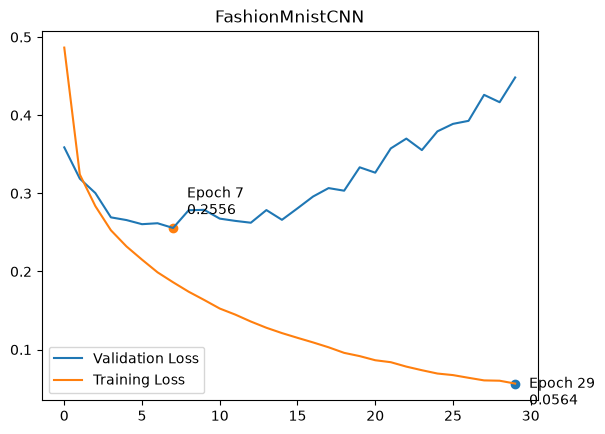

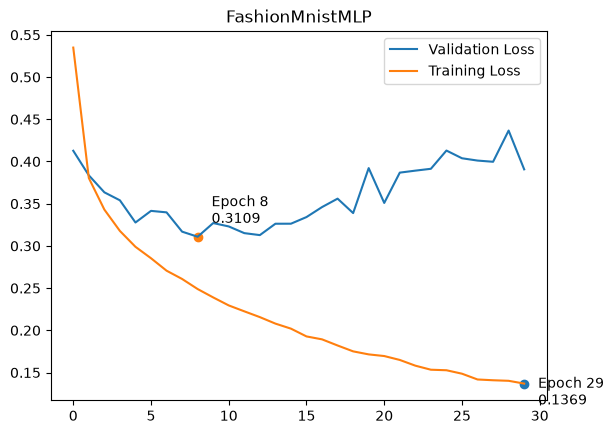

In [58]:
plot_train_val_loss_curve(cnn_train_losses, cnn_val_losses, "FashionMnistCNN")
plot_train_val_loss_curve(mlp_train_losses, mlp_val_losses, "FashionMnistMLP")

- According to train vs validation loss CNN reached minimum validation loss first and under same number of epoch CNN has minimum training loss and considering difference in number of parameters it is considerable advantage and this too is expected as CNN also considers nearby pixel which leads to better learning compare to MLP despite having less learnable parameters. 
- CNN learns the training data more effectively and achieves better validation performance, but its generalization begins to deteriorate substantially after the early epochs.

### Comparing training accuracy vs validation accuracy

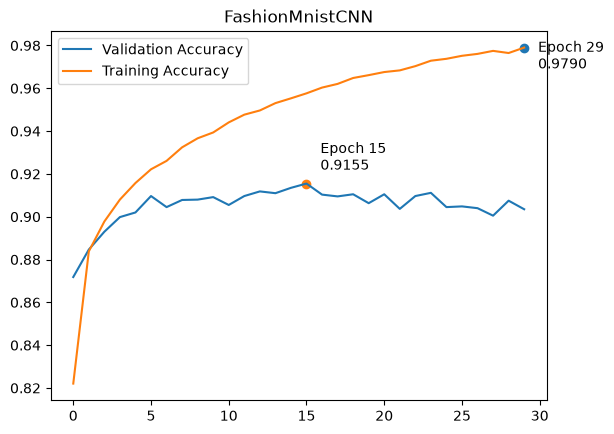

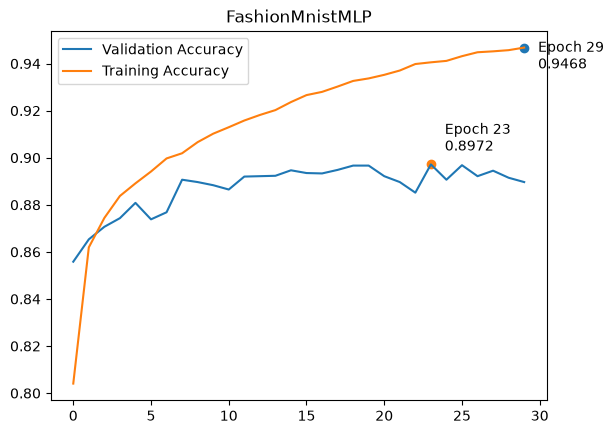

In [59]:
plot_train_val_accuracy_curve(cnn_train_accuracies, cnn_val_accuracies, "FashionMnistCNN")
plot_train_val_accuracy_curve(mlp_train_accuracies, mlp_val_accuracies, "FashionMnistMLP")

- Same as train-val loss in accuracy too CNN reaches it best validation accuracy first and it also has last highest training accuracy this also indicates that CNN is better at image classification tasks then MLP. But after early epoch it's generalization begins to deteriorate.

## Confusion Matrix

Confusion Matrix of MLP:


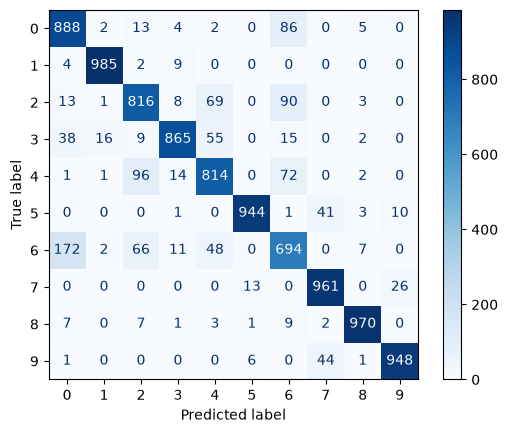

Confusion Matrix of CNN:


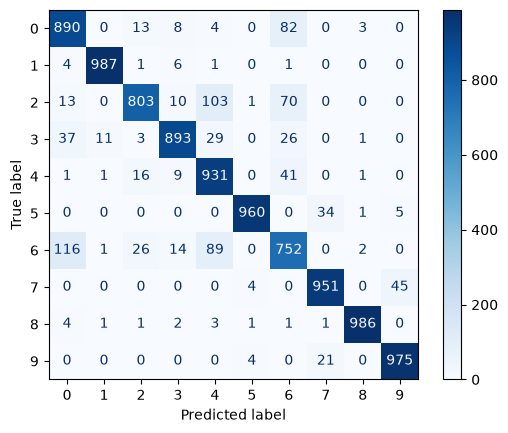

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

mlp_model = FashionMnistMLP()
cnn_model = FashionMnistCNN()

mlp_model.load_state_dict(torch.load("best_mlp.pt", weights_only=True))
cnn_model.load_state_dict(torch.load("best_cnn.pt", weights_only=True))

mlp_model.eval()
cnn_model.eval()

with torch.no_grad():

    mlp_pred = mlp_model(test_images)
    mlp_pred = mlp_pred.argmax(dim=1)
    
    print(f"Confusion Matrix of MLP:")

    cm_mlp = confusion_matrix(test_labels, mlp_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_mlp)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

    cnn_pred = cnn_model(test_images)
    cnn_pred = cnn_pred.argmax(dim=1)
    
    print(f"Confusion Matrix of CNN:")

    cm_cnn = confusion_matrix(test_labels, cnn_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnn)
    disp.plot(cmap=plt.cm.Blues)
    plt.show()

- On many instances CNN is still misidentifying some classes. Especially class '6' which is being identified as many different classes.

## Comparing metrics

In [61]:
from sklearn.metrics import classification_report

print(f"MLP: \n{classification_report(test_labels, mlp_pred)}")
print(f"CNN: \n{classification_report(test_labels, cnn_pred)}")

MLP: 
              precision    recall  f1-score   support

           0       0.79      0.89      0.84      1000
           1       0.98      0.98      0.98      1000
           2       0.81      0.82      0.81      1000
           3       0.95      0.86      0.90      1000
           4       0.82      0.81      0.82      1000
           5       0.98      0.94      0.96      1000
           6       0.72      0.69      0.71      1000
           7       0.92      0.96      0.94      1000
           8       0.98      0.97      0.97      1000
           9       0.96      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

CNN: 
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1000
           1       0.99      0.99      0.99      1000
           2       0.93      0.80      0.86      1000
           3

- According to the metric comparison CNN has better precision, recall and fi-score though gap is minor but considering 7 times less parameters than MLP it is significant. 

## Final Verdict

- The CNN outperformed the MLP on FashionMNIST under the same training conditions. The CNN achieved a higher best validation accuracy (91.90% vs 89.93%) and lower minimum validation loss (0.2461 vs 0.3060).

- The CNN also used only 36,682 trainable parameters compared with 279,490 for the MLP, approximately 7.6× fewer parameters. This is primarily due to convolutional layers using local receptive fields and shared weights rather than fully connecting every input pixel to every neuron.

- The CNN also achieved higher test performance, with approximately 92.33% accuracy compared with approximately 89.47% for the MLP. Its class-level performance improved particularly for classes such as 2, 4, 5, and 7.

- However, both models exhibited overfitting. The CNN showed a particularly large gap between training and validation performance, with training accuracy reaching 98.16% while validation accuracy remained around 90–92%. Class 6 remained a major failure mode for both models.

- Therefore, the results support the conclusion that the tested CNN architecture is better suited to FashionMNIST than the tested MLP architecture, while also showing that the CNN requires better regularization or training control to improve generalization.